In [106]:
import csv
import glob
import os

def create_csv(file_name):
    #create csv with heading
    with open(file_name, 'w', newline='',encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        #writer.writerow(['nr', 'bid','brewery','name','kind', 'link','abv','ibu', 'rating','nr_raters','adding_date','text'])

def beer_to_csv(data,file_name):
    #add new entry into csv
    with open(file_name, 'a', newline='',encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(data)

def Open_Csv(name):
    with open(name, "r+", encoding="utf-8") as file:
        reader = csv.reader(file)
        data=[]
        for row in reader:
            data.append(row)
    return data

def Look_Eliminate_Duplicates(in_data):
    seen = set()
    filtered_data = []

    for row in in_data:
        value = row[1]
        if value not in seen:
            seen.add(value)
            filtered_data.append(row)
    
    return filtered_data

def Keyword_Matching(in_beer_data):
    for row in in_beer_data:
        if ("malt" in row[11]) or ("maláta" in row[11]):
            row.append(1) #row no 12
        else:
            row.append(0)
        if ("hops" in row[11]) or ("komló" in row[11]):
            row.append(1) #row no 13
        else:
            row.append(0)
        if ("chocolate" in row[11]) or ("csokoládé" in row[11])or ("csoki" in row[11]):
            row.append(1) #row no 14
        else:
            row.append(0)
        if ("German" in row[11]) or ("német" in row[11])or ("german" in row[11]):
            row.append(1) #row no 15
        else:
            row.append(0)
        if ("banana" in row[11]) or ("banán" in row[11]):
            row.append(1) #row no 16
        else:
            row.append(0)
        if ("vanilla" in row[11]) or ("vanília" in row[11]):
            row.append(1) #row no 17
        else:
            row.append(0)
        if ("caramel" in row[11]) or ("karamella" in row[11]):
            row.append(1) #row no 18
        else:
            row.append(0)
        if ("yeast" in row[11]) or ("élesztő" in row[11]):
            row.append(1) #row no 19
        else:
            row.append(0)
        if ("fruit" in row[11]) or ("gyümölcs" in row[11]) or ("berry" in row[11])or ("berries" in row[11]):
            row.append(1) #row no 20
        else:
            row.append(0)
        if ("bourbon" in row[11]) or ("whiskey" in row[11]):
            row.append(1) #row no 21
        else:
            row.append(0)
        if ("rhum" in row[11]) or ("rum" in row[11]):
            row.append(1) #row no 22
        else:
            row.append(0)
        if ("alcohol" in row[11]) or ("alkohol" in row[11]):
            row.append(1) #row no 23
        else:
            row.append(0)
        if ("gluten" in row[11]) or ("glutén" in row[11]):
            row.append(1) #row no 24
        else:
            row.append(0)
        if ("barrel" in row[11]) or ("hordó" in row[11]):
            row.append(1) #row no 25
        else:
            row.append(0)
        if ("rye" in row[11]) or ("rozs" in row[11]):
            row.append(1) #row no 26
        else:
            row.append(0)
        if ("barley" in row[11]) or ("árpa" in row[11]):
            row.append(1) #row no 27
        else:
            row.append(0)
        if ("cocoa" in row[11]) or ("kakaó" in row[11]):
            row.append(1) #row no 28
        else:
            row.append(0)
        if ("alacsony" in row[11]) or ("alsó" in row[11]) or ("kicsi" in row[11]) or ("kevés" in row[11]) or ("pici" in row[11]) or ("hideg" in row[11]):
            row.append(1) #row no 29
        else:
            row.append(0)
        if ("magas" in row[11]) or ("felső" in row[11]) or ("nagy" in row[11]) or ("sok" in row[11]) or ("meleg" in row[11]):
            row.append(1) #row no 30
        else:
            row.append(0)
        if row[1] == "3169618": #Sörművek Marzen is not properli filled out in untappd
            row[6] = "5.0"
    return in_beer_data

def Normalize(unnorm_data):
    for row in unnorm_data:
        if (row[6] != "abv") and (row[8] != "rating"):
            row[6] = float(row[6])/15 #normalize ABV with 15 as arbitrary number
            row[8] = float(row[8])/5#normalize rating with 5 as the maximum rating
        #no else branch
    return unnorm_data

#QA
#1 remove duplications from both csv-s
#remove duplicates from Top50
Top50Data=Open_Csv("../Scraper/Top50Data.csv")
Top50Data = Look_Eliminate_Duplicates(Top50Data)
#remove duplicates from AllData
AllData=Open_Csv("../Scraper/AllData.csv")
AllData = Look_Eliminate_Duplicates(AllData)
#remove Top50Data from AllData based on row[1]
top_keys = {row[1] for row in Top50Data}
AllData = [row for row in AllData if row[1] not in top_keys]

#2 set up 3 csv-s based on the 2 with cutoff / treshold value
treshold=3.85
good_beers = []
rest_beers = []
for row in AllData:
    try:
        value = float(row[8])
        if value > treshold:
            good_beers.append(row)
        else:
            rest_beers.append(row)

    except (ValueError, IndexError):
        pass
        
#3 normalization and adding one hot encoding variables and other new variables
datas=[Top50Data,good_beers,rest_beers]
for data_type in datas:
    data_type = Keyword_Matching(data_type)
    data_type = Normalize(data_type)

#4 export Csvs
#remove all the CSVs from the folder
csv_files = glob.glob("*.csv")
for file in csv_files:
   os.remove(file)
   print(f"Törölve: {file}")
    
files=["TopBeerData.csv","GoodBeerData.csv","RestBeerData.csv"]
for i in range (0,len(files)):
    create_csv(files[i])
    beer_to_csv(datas[i],files[i])
    print(f"{files[i]} file created")

Törölve: GoodBeerData.csv
Törölve: RestBeerData.csv
Törölve: TopBeerData.csv
TopBeerData.csv file created
GoodBeerData.csv file created
RestBeerData.csv file created


In [107]:
#DV: rating row[8]
#IDVs: abv - row[6], raters - row[9], text - row[12]-row[30]
from sklearn.linear_model import LinearRegression
import numpy as np

datas=[Top50Data,good_beers,rest_beers]
for data in datas:
    #data = data[1:]
    numeric_data = []
    for row in data[1:]: #ignore heading
        numeric_data.append([
            float(row[6]), #abv
            float(row[9]), #
            float(row[12]),
            float(row[13]),
            float(row[14]),
            float(row[15]),
            float(row[16]),
            float(row[17]),#
            float(row[18]),#
            float(row[19]),
            float(row[20]),
            float(row[21]),
            float(row[22]),
            float(row[23]),
            float(row[24]),
            float(row[25]),
            float(row[26]),
            float(row[27]),
            float(row[28]),
            float(row[29]),
            float(row[30]),
            float(row[8])
        ])
    numeric_data = np.array(numeric_data)
    #print(numeric_data)
    X = numeric_data[:, :-1]
    y = numeric_data[:, -1]
    model = LinearRegression()
    model.fit(X, y)
    #r2 = r2_score(y, y_pred)
    #corr = np.corrcoef(y, y_pred)[0, 1]
    print("coefs",model.coef_)
    print("intercept",model.intercept_)
    #print("R²:", r2)
    #print("Correlation:", corr)

coefs [-7.97754200e-04  3.95214028e-06 -1.49408364e-03  1.70315787e-04
 -2.47083010e-03 -2.41743375e-03  0.00000000e+00  1.20534915e-02
  3.64512689e-02  1.17021803e-02 -4.24383952e-03 -5.07601161e-03
  6.58718822e-03 -2.41743375e-03  9.75781955e-19  3.36150996e-04
 -2.42254855e-02  0.00000000e+00  6.29963544e-03  2.66176423e-03
 -9.44678919e-03]
intercept 0.8192770684444837
coefs [ 1.88895495e-02  3.72097626e-06 -1.25535457e-03  8.16948434e-03
  3.94308184e-03  7.94446632e-03  1.07333926e-02  4.71118254e-03
 -3.82338204e-03 -2.02493162e-03 -5.61585977e-04  7.36274118e-04
  3.33653211e-03 -1.04930114e-02  4.33680869e-19  2.16726951e-03
  8.99153158e-03 -5.33200620e-03 -1.52106485e-03  2.69598953e-03
  1.05552528e-03]
intercept 0.7697065795090536
coefs [ 1.31479338e-01 -5.20474674e-06 -2.19696777e-03  1.08800254e-02
  3.90215555e-03 -1.69605938e-03 -1.07631041e-02  1.59528136e-02
 -6.29845800e-03  5.37301938e-03  1.07862404e-02 -1.56048685e-03
 -1.19719810e-03 -5.69268497e-03 -7.9908388

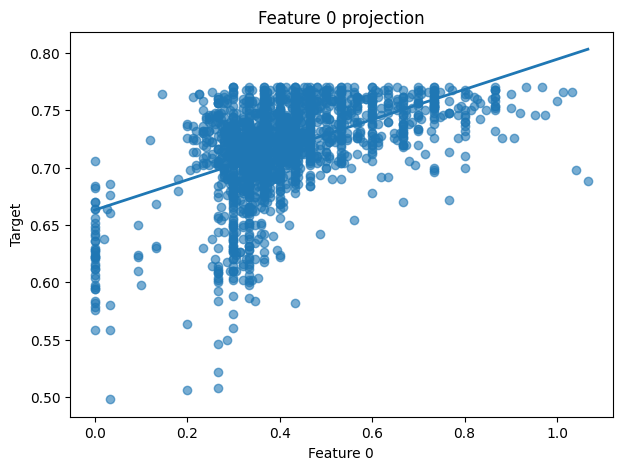

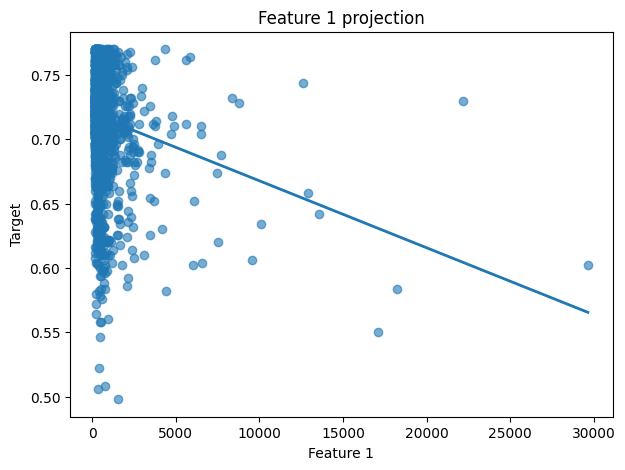

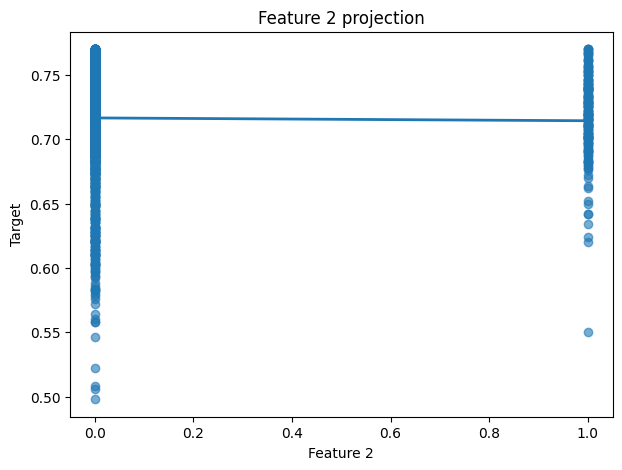

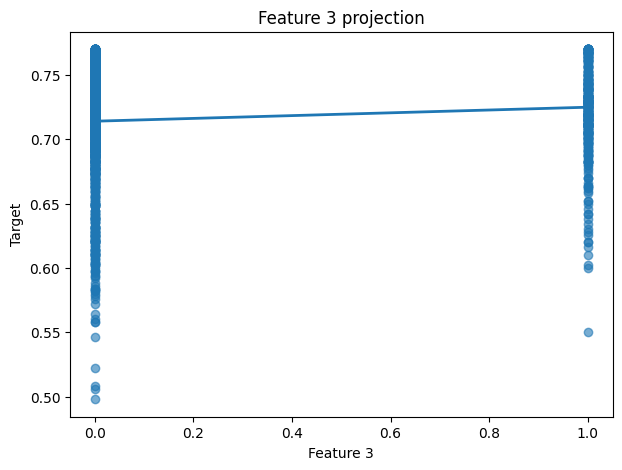

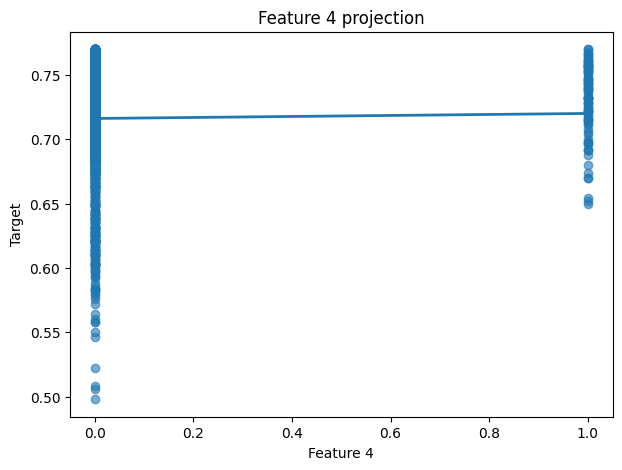

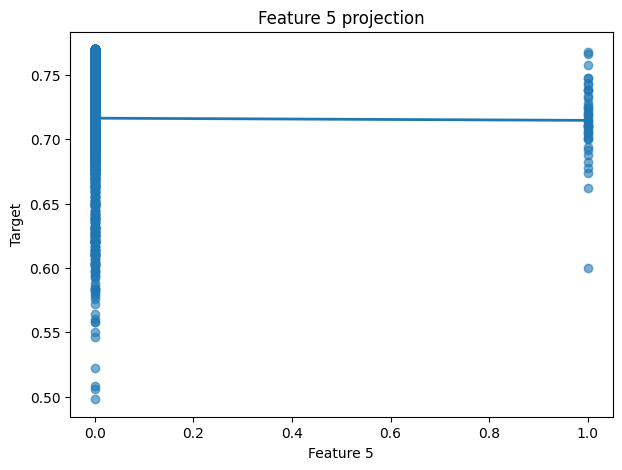

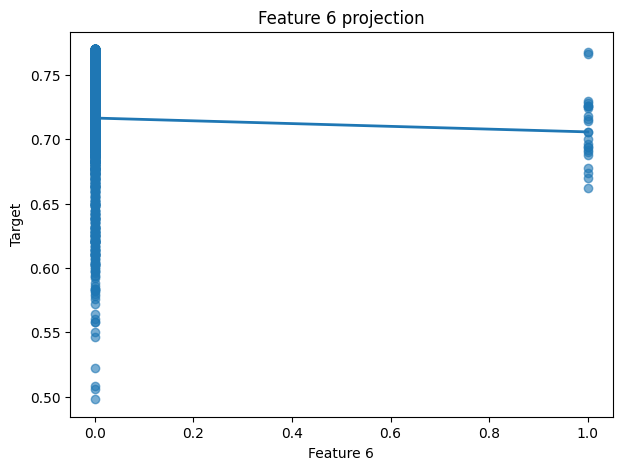

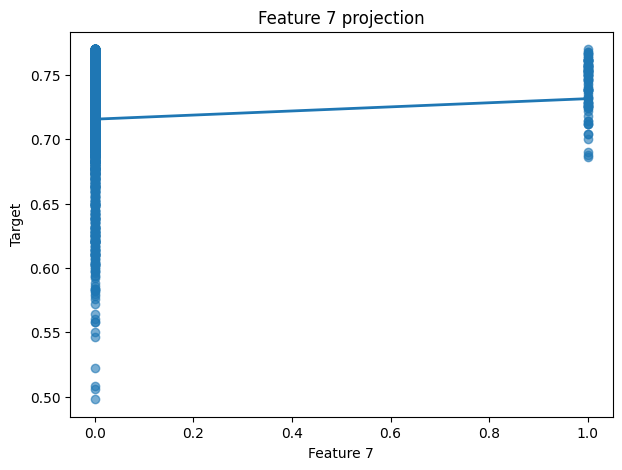

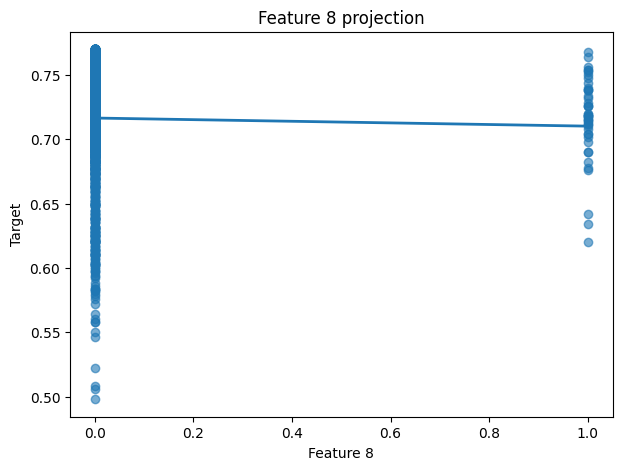

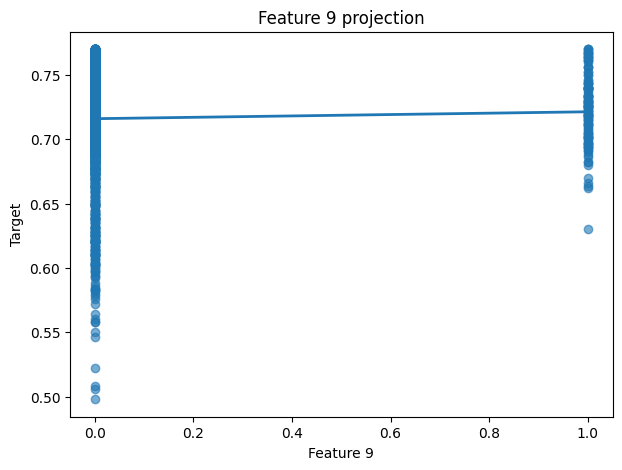

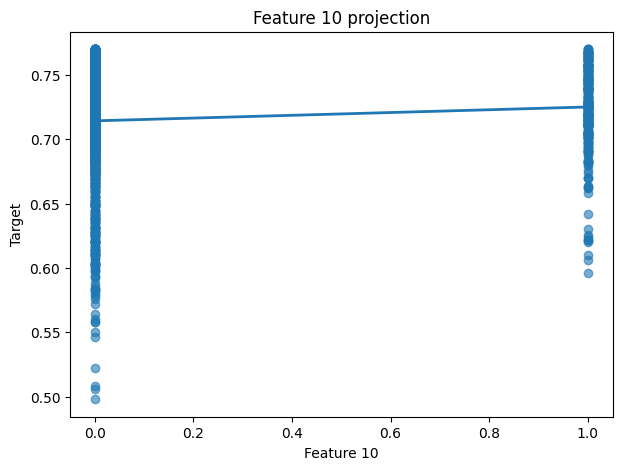

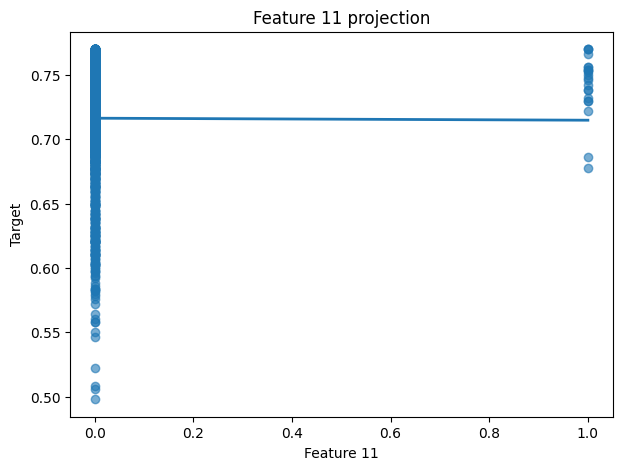

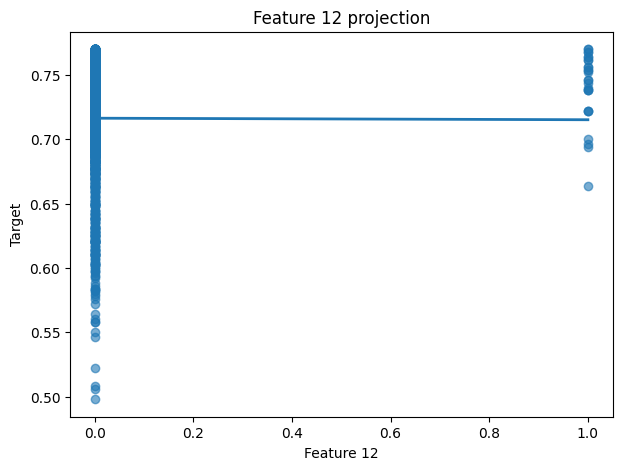

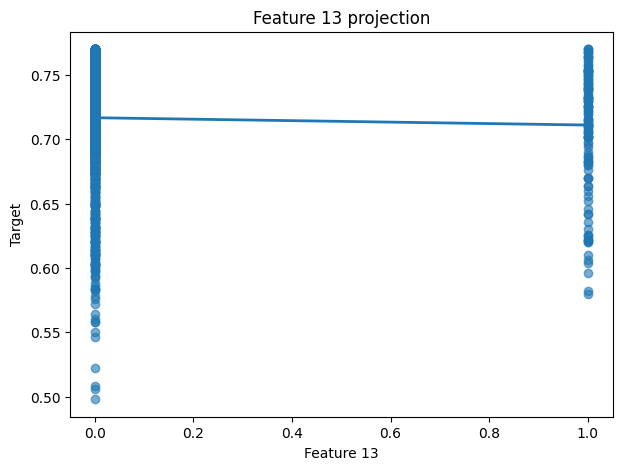

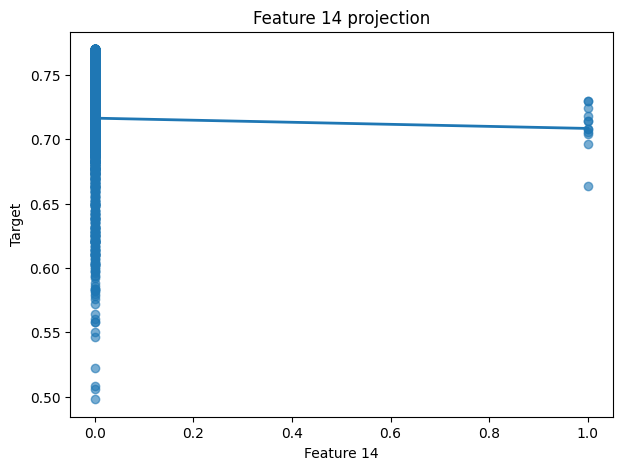

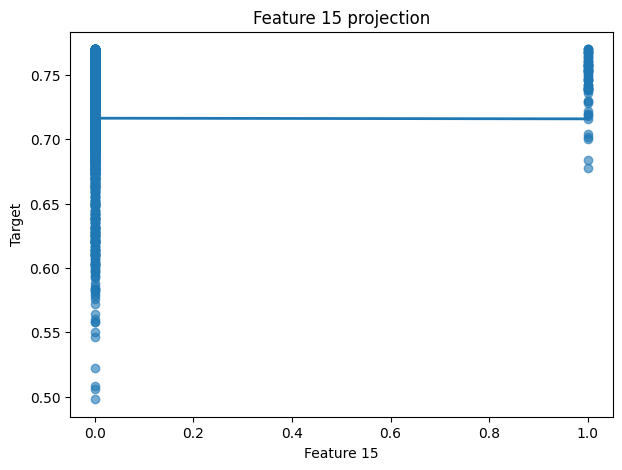

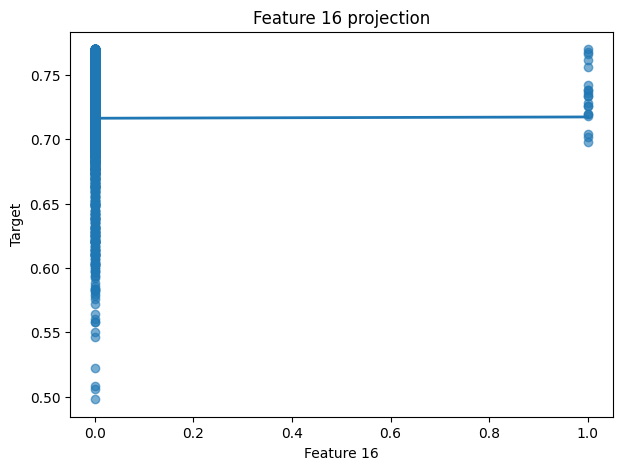

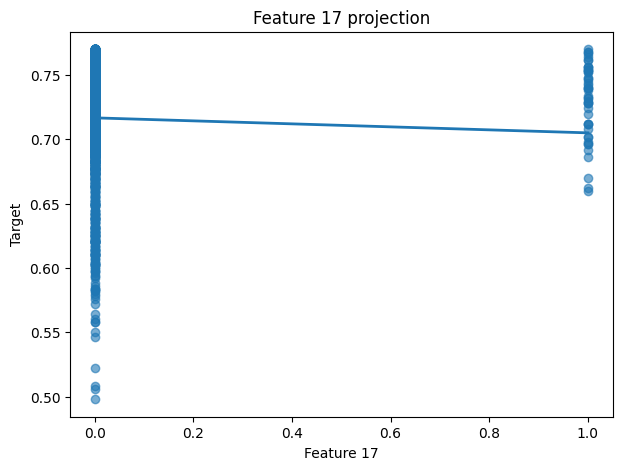

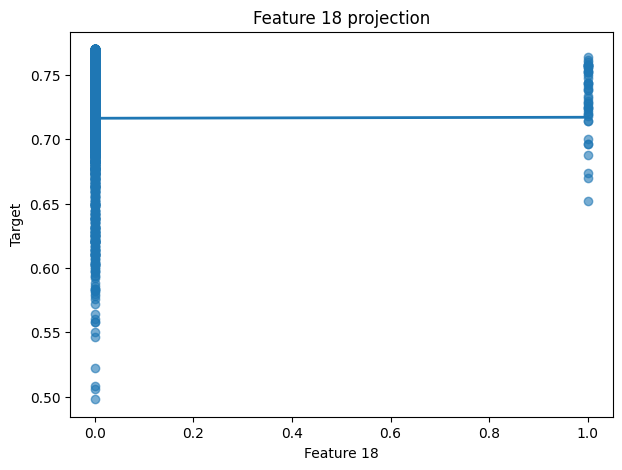

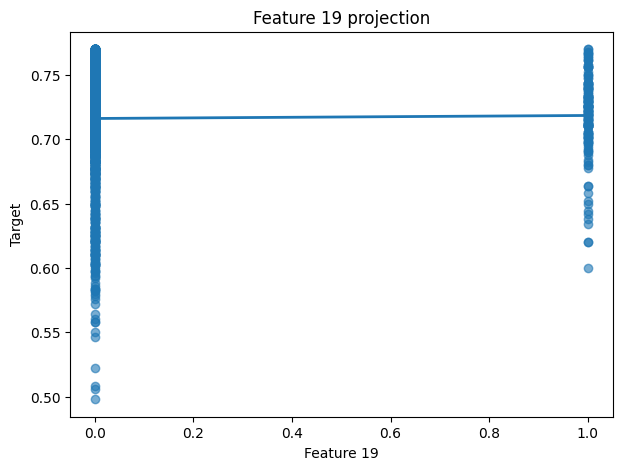

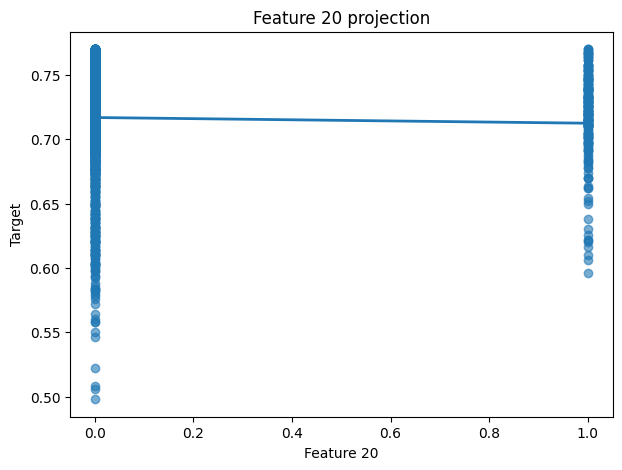

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =========================
# MODEL FIT
# =========================

model = LinearRegression()

model.fit(X, y)

# =========================
# PLOTS
# =========================

n_features = X.shape[1]

for feature_idx in range(n_features):

    plt.figure(figsize=(7, 5))

    # -------------------------
    # scatter pontok
    # -------------------------

    x_feature = X[:, feature_idx]

    plt.scatter(
        x_feature,
        y,
        alpha=0.6
    )

    # -------------------------
    # regressziós vetület
    # -------------------------

    x_line = np.linspace(
        x_feature.min(),
        x_feature.max(),
        200
    )

    # minden feature átlagra
    X_line = np.tile(
        X.mean(axis=0),
        (200, 1)
    )

    # csak ez az egy feature változik
    X_line[:, feature_idx] = x_line

    # predikció
    y_line = model.predict(X_line)

    # görbe/egyenes
    plt.plot(
        x_line,
        y_line,
        linewidth=2
    )

    # -------------------------
    # labels
    # -------------------------

    plt.xlabel(f"Feature {feature_idx}")
    plt.ylabel("Target")

    plt.title(
        f"Feature {feature_idx} projection"
    )

    plt.show()